In [1]:
!pip install -q groq sentence-transformers faiss-cpu pypdf langchain langchain-community streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.5/334.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
from google.colab import files
import os

os.makedirs("slides", exist_ok=True)
print("13 PDF slaytının hepsini birden seç ve yükle:")
uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, f"slides/{filename}")

print(f"\n✅ {len(os.listdir('slides'))} dosya yüklendi:")
for f in sorted(os.listdir("slides")):
    print(f"  - {f}")

13 PDF slaytının hepsini birden seç ve yükle:


Saving 2_EditDistance_Jan_08_2020.pdf to 2_EditDistance_Jan_08_2020.pdf
Saving 2_TextProc_Mar_25_2021.pdf to 2_TextProc_Mar_25_2021.pdf
Saving 2.pdf to 2.pdf
Saving 3_LM_Jan_08_2021.pdf to 3_LM_Jan_08_2021.pdf
Saving 3.pdf to 3.pdf
Saving 6_Vector_Apr18_2021.pdf to 6_Vector_Apr18_2021.pdf
Saving 6.pdf to 6.pdf
Saving BERT.pdf to BERT.pdf
Saving Convolutional Neural Networks.pdf to Convolutional Neural Networks.pdf
Saving Deep Learning for Computer Vision.pdf to Deep Learning for Computer Vision.pdf
Saving Making Transformers Efficient in Production.pdf to Making Transformers Efficient in Production.pdf
Saving Neural Network, Back-Propagation.pdf to Neural Network, Back-Propagation.pdf
Saving Vector Database.pdf to Vector Database.pdf

✅ 13 dosya yüklendi:
  - 2.pdf
  - 2_EditDistance_Jan_08_2020.pdf
  - 2_TextProc_Mar_25_2021.pdf
  - 3.pdf
  - 3_LM_Jan_08_2021.pdf
  - 6.pdf
  - 6_Vector_Apr18_2021.pdf
  - BERT.pdf
  - Convolutional Neural Networks.pdf
  - Deep Learning for Computer Vis

In [4]:
import os

from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Grok keyini yapıştır")

print("✅ Key saved")

Grok keyini yapıştır··········
✅ Key saved


In [6]:
!pip install -q langchain-text-splitters

In [7]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os, glob

all_docs = []
pdf_files = sorted(glob.glob("slides/*.pdf"))
print(f"Found {len(pdf_files)} PDF files. Loading...\n")

for pdf in pdf_files:
    loader = PyPDFLoader(pdf)
    docs = loader.load()
    for d in docs:
        d.metadata["source"] = os.path.basename(pdf)
    all_docs.extend(docs)
    print(f"  [OK] {os.path.basename(pdf)} - {len(docs)} pages")

print(f"\nTotal pages loaded: {len(all_docs)}")

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=["\n\n", "\n", ". ", " ", ""]
)
chunks = splitter.split_documents(all_docs)
print(f"Total chunks created: {len(chunks)}")

Found 13 PDF files. Loading...



  [OK] 2.pdf - 29 pages


  [OK] 2_EditDistance_Jan_08_2020.pdf - 52 pages
  [OK] 2_TextProc_Mar_25_2021.pdf - 71 pages


  [OK] 3.pdf - 29 pages
  [OK] 3_LM_Jan_08_2021.pdf - 77 pages


  [OK] 6.pdf - 34 pages


  [OK] 6_Vector_Apr18_2021.pdf - 106 pages


  [OK] BERT.pdf - 77 pages
  [OK] Convolutional Neural Networks.pdf - 2 pages
  [OK] Deep Learning for Computer Vision.pdf - 4 pages


  [OK] Making Transformers Efficient in Production.pdf - 45 pages
  [OK] Neural Network, Back-Propagation.pdf - 2 pages
  [OK] Vector Database.pdf - 77 pages

Total pages loaded: 605
Total chunks created: 1429


In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np

print("Downloading embedding model (first run takes ~30s)...")
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Embedding model loaded.")

texts = [c.page_content for c in chunks]
print(f"\nEncoding {len(texts)} chunks into embeddings...")
embeddings = embed_model.encode(texts, show_progress_bar=True, batch_size=64)
embeddings = np.array(embeddings).astype("float32")
print(f"Embedding matrix shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.

Encoding 1429 chunks into embeddings...


Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Embedding matrix shape: (1429, 384)


In [9]:
import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(embeddings)
print(f"FAISS index ready. Total vectors: {index.ntotal}")

def retrieve(query, k=5):
    q_emb = embed_model.encode([query]).astype("float32")
    distances, indices = index.search(q_emb, k)
    results = []
    for i, idx in enumerate(indices[0]):
        results.append({
            "text": chunks[idx].page_content,
            "source": chunks[idx].metadata.get("source", "?"),
            "page": chunks[idx].metadata.get("page", "?"),
            "score": float(distances[0][i])
        })
    return results

test = retrieve("What is a transformer?", k=3)
print(f"\nTest query: 'What is a transformer?'\n")
for i, r in enumerate(test, 1):
    print(f"[{i}] {r['source']} (page {r['page']}) - score: {r['score']:.3f}")
    print(f"    {r['text'][:150]}...\n")

FAISS index ready. Total vectors: 1429

Test query: 'What is a transformer?'

[1] Making Transformers Efficient in Production.pdf (page 0) - score: 0.897
    Making Transformers
Efficient in Production...

[2] BERT.pdf (page 17) - score: 0.910
    The TransformerArchitecture
•the original Transformer is based on the encoder-decoder architecture that
is widely used for tasks like machine translat...

[3] BERT.pdf (page 0) - score: 0.958
    Hello Transformers...



In [12]:
import os
from getpass import getpass

raw = getpass("Paste ONLY the Groq API key (starts with 'gsk_'): ")
# Strip any whitespace, emojis, or hidden characters
clean = raw.strip().encode("ascii", errors="ignore").decode("ascii")
os.environ["GROQ_API_KEY"] = clean
print(f"Key length: {len(clean)} characters")
print(f"Starts with: {clean[:4]}")

Paste ONLY the Groq API key (starts with 'gsk_'): ··········
Key length: 56 characters
Starts with: gsk_


In [13]:
from groq import Groq
import time

client = Groq(api_key=os.environ["GROQ_API_KEY"])

SYSTEM_PROMPT = """You are a helpful teaching assistant for an "Introduction to LLM" course.
Answer the student's question using ONLY the provided context from the lecture slides.
If the answer is not in the context, say "This topic is not covered in the provided lecture slides."
Be concise, clear, and educational. Cite which slide/source you used."""

def ask(question, k=5):
    t0 = time.time()
    retrieved = retrieve(question, k=k)
    context = "\n\n---\n\n".join(
        [f"[Source: {r['source']}, page {r['page']}]\n{r['text']}" for r in retrieved]
    )
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Context from lecture slides:\n\n{context}\n\nQuestion: {question}"}
    ]
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=messages,
        temperature=0.2,
        max_tokens=600,
    )
    answer = response.choices[0].message.content
    elapsed = time.time() - t0
    return {
        "question": question,
        "answer": answer,
        "sources": [(r["source"], r["page"]) for r in retrieved],
        "time": elapsed
    }

# Test
result = ask("What is the difference between BERT and GPT?")
print("Q:", result["question"])
print("\nA:", result["answer"])
print(f"\nSources: {result['sources']}")
print(f"Time: {result['time']:.2f} s")

Q: What is the difference between BERT and GPT?

A: The main difference between BERT and GPT is their pretraining objectives. BERT is pretrained on masked language modeling, where the model predicts the most likely candidates for the masked words (Source: BERT.pdf, page 16). In contrast, GPT is pretrained by predicting the next word based on the previous ones (Source: BERT.pdf, page 67). This difference in pretraining objectives allows BERT to be more suitable for NLU tasks, while GPT is more suitable for NLG tasks.

Sources: [('BERT.pdf', 74), ('BERT.pdf', 16), ('BERT.pdf', 68), ('BERT.pdf', 67), ('BERT.pdf', 60)]
Time: 0.56 s


In [14]:
import json

test_questions = [
    "What is a transformer and how does it work?",
    "Explain the self-attention mechanism.",
    "What is the difference between BERT and GPT?",
    "What is Named Entity Recognition (NER)?",
    "How does knowledge distillation make transformers more efficient?",
    "What is a vector database and why is it used?",
    "Explain Retrieval Augmented Generation (RAG).",
    "What are the main components of a convolutional neural network?",
    "What is fine-tuning in the context of LLMs?",
    "What is the role of positional encoding in transformers?",
]

results = []
print(f"Running evaluation on {len(test_questions)} questions...\n")
print("=" * 80)

for i, q in enumerate(test_questions, 1):
    r = ask(q)
    results.append(r)
    print(f"\n[{i}/{len(test_questions)}] Q: {q}")
    print(f"A: {r['answer'][:200]}...")
    print(f"Sources: {r['sources'][:3]}")
    print(f"Time: {r['time']:.2f}s")
    print("-" * 80)

# Aggregate metrics
avg_time = sum(r["time"] for r in results) / len(results)
total_chunks_retrieved = sum(len(r["sources"]) for r in results)

print(f"\n{'=' * 80}")
print("EVALUATION SUMMARY")
print(f"{'=' * 80}")
print(f"Total questions: {len(results)}")
print(f"Average response time: {avg_time:.2f} seconds")
print(f"Total chunks retrieved: {total_chunks_retrieved}")
print(f"Total vectors in index: {index.ntotal}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Embedding model: all-MiniLM-L6-v2")
print(f"LLM: llama-3.3-70b-versatile (via Groq)")

# Save results to JSON for the report
with open("evaluation_results.json", "w") as f:
    json.dump([{
        "question": r["question"],
        "answer": r["answer"],
        "sources": [{"file": s[0], "page": s[1]} for s in r["sources"]],
        "time_seconds": round(r["time"], 3)
    } for r in results], f, indent=2)

print("\nResults saved to evaluation_results.json")

Running evaluation on 10 questions...


[1/10] Q: What is a transformer and how does it work?
A: A Transformer is based on the encoder-decoder architecture, which consists of two components: 
1. The Encoder: Converts an input sequence of tokens into a sequence of embedding vectors, often called t...
Sources: [('BERT.pdf', 17), ('Making Transformers Efficient in Production.pdf', 0), ('BERT.pdf', 0)]
Time: 0.50s
--------------------------------------------------------------------------------

[2/10] Q: Explain the self-attention mechanism.
A: The self-attention mechanism is a process that allows neural networks to assign a different amount of weight or "attention" to each element in a sequence. In the context of text sequences, this means ...
Sources: [('BERT.pdf', 9), ('BERT.pdf', 28), ('BERT.pdf', 11)]
Time: 0.55s
--------------------------------------------------------------------------------

[3/10] Q: What is the difference between BERT and GPT?
A: The main difference between BERT a

In [16]:
from textwrap import fill

print("=" * 90)
print(" " * 30 + "RAG SYSTEM EVALUATION")
print("=" * 90)
print(f"Embedding model : all-MiniLM-L6-v2 (dim=384)")
print(f"Vector store    : FAISS IndexFlatL2")
print(f"LLM             : llama-3.3-70b-versatile (Groq)")
print(f"Total vectors   : {index.ntotal}")
print(f"Total questions : {len(results)}")
print(f"Avg latency     : {avg_time:.2f} seconds")
print("=" * 90)

for i, r in enumerate(results, 1):
    print(f"\n[Q{i}] {r['question']}")
    print("-" * 90)
    wrapped = fill(r['answer'], width=88, initial_indent="  ", subsequent_indent="  ")
    print(wrapped)
    srcs = ", ".join([f"{s[0]} (p.{s[1]})" for s in r['sources'][:3]])
    print(f"\n  Sources: {srcs}")
    print(f"  Latency: {r['time']:.2f}s")
    print("=" * 90)

                              RAG SYSTEM EVALUATION
Embedding model : all-MiniLM-L6-v2 (dim=384)
Vector store    : FAISS IndexFlatL2
LLM             : llama-3.3-70b-versatile (Groq)
Total vectors   : 1429
Total questions : 10
Avg latency     : 0.46 seconds

[Q1] What is a transformer and how does it work?
------------------------------------------------------------------------------------------
  A Transformer is based on the encoder-decoder architecture, which consists of two
  components:  1. The Encoder: Converts an input sequence of tokens into a sequence of
  embedding vectors, often called the hidden state or context. 2. The Decoder: Uses the
  encoder's hidden state to iteratively generate an output sequence of tokens, one token
  at a time.  This architecture is widely used for tasks like machine translation.
  (Source: BERT.pdf, page 17)

  Sources: BERT.pdf (p.17), Making Transformers Efficient in Production.pdf (p.0), BERT.pdf (p.0)
  Latency: 0.50s

[Q2] Explain the self-at

In [19]:
app_code = '''
import streamlit as st
import os, glob, time, pickle
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from groq import Groq

st.set_page_config(page_title="LLM Course RAG Assistant", page_icon="📚", layout="wide")

@st.cache_resource
def load_system():
    embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    with open("rag_data.pkl", "rb") as f:
        data = pickle.load(f)
    index = faiss.deserialize_index(data["index_bytes"])
    return embed_model, index, data["chunks"]

embed_model, index, chunks = load_system()
client = Groq(api_key=os.environ["GROQ_API_KEY"])

SYSTEM_PROMPT = """You are a helpful teaching assistant for an "Introduction to LLM" course.
Answer the student's question using ONLY the provided context from the lecture slides.
If the answer is not in the context, say "This topic is not covered in the provided lecture slides."
Be concise, clear, and educational. Cite which slide/source you used."""

def retrieve(query, k=5):
    q_emb = embed_model.encode([query]).astype("float32")
    D, I = index.search(q_emb, k)
    return [{"text": chunks[idx]["text"], "source": chunks[idx]["source"],
             "page": chunks[idx]["page"], "score": float(D[0][i])}
            for i, idx in enumerate(I[0])]

def ask(question, k=5):
    t0 = time.time()
    retrieved = retrieve(query=question, k=k)
    context = "\\n\\n---\\n\\n".join(
        [f"[Source: {r['source']}, page {r['page']}]\\n{r['text']}" for r in retrieved])
    resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "system", "content": SYSTEM_PROMPT},
                  {"role": "user", "content": f"Context:\\n\\n{context}\\n\\nQuestion: {question}"}],
        temperature=0.2, max_tokens=600)
    return resp.choices[0].message.content, retrieved, time.time() - t0

st.title("📚 Intro to LLM — RAG Assistant")
st.caption("Ask any question about the lecture slides. Powered by FAISS + Llama 3.3 70B (Groq).")

with st.sidebar:
    st.header("System Info")
    st.write(f"**Total vectors:** {index.ntotal}")
    st.write(f"**Embedding dim:** 384")
    st.write(f"**Embedding model:** all-MiniLM-L6-v2")
    st.write(f"**LLM:** llama-3.3-70b-versatile")
    st.write(f"**Vector store:** FAISS (IndexFlatL2)")
    st.divider()
    st.subheader("Example questions")
    examples = [
        "What is self-attention?",
        "Difference between BERT and GPT?",
        "Explain knowledge distillation.",
        "What is a vector database?",
    ]
    for ex in examples:
        if st.button(ex, use_container_width=True):
            st.session_state["q"] = ex

question = st.text_input("Your question:", value=st.session_state.get("q", ""),
                         placeholder="e.g. What is the Transformer architecture?")

if st.button("Ask", type="primary") and question:
    with st.spinner("Retrieving and generating..."):
        answer, sources, elapsed = ask(question)
    st.success(f"Answered in {elapsed:.2f}s")
    st.markdown("### Answer")
    st.write(answer)
    st.markdown("### Retrieved sources")
    for i, s in enumerate(sources, 1):
        with st.expander(f"[{i}] {s['source']} — page {s['page']} (score: {s['score']:.3f})"):
            st.write(s["text"])
'''

with open("app.py", "w") as f:
    f.write(app_code)

# Save the RAG data so Streamlit can load it
import pickle
chunks_data = [{"text": c.page_content,
                "source": c.metadata.get("source", "?"),
                "page": c.metadata.get("page", "?")} for c in chunks]
with open("rag_data.pkl", "wb") as f:
    pickle.dump({"index_bytes": faiss.serialize_index(index),
                 "chunks": chunks_data}, f)

print("app.py and rag_data.pkl saved.")
print(f"rag_data.pkl size: {os.path.getsize('rag_data.pkl') / 1024 / 1024:.1f} MB")

app.py and rag_data.pkl saved.
rag_data.pkl size: 2.9 MB


In [25]:
# Ground-truth evaluation set: question -> expected source file(s)
# File-level matching: a question is counted correct if any of its gold
# sources appears among the top-k retrieved chunks.
eval_set = [
    {"q": "What is a transformer and how does it work?",            "gold": ["BERT.pdf"]},
    {"q": "Explain the self-attention mechanism.",                   "gold": ["BERT.pdf"]},
    {"q": "What is the difference between BERT and GPT?",            "gold": ["BERT.pdf"]},
    {"q": "What is masked language modeling?",                       "gold": ["BERT.pdf"]},
    {"q": "What is positional encoding in transformers?",            "gold": ["BERT.pdf"]},
    {"q": "What is Named Entity Recognition?",                       "gold": ["BERT.pdf"]},
    {"q": "How does knowledge distillation work?",                   "gold": ["Making Transformers Efficient in Production.pdf"]},
    {"q": "What is model quantization?",                             "gold": ["Making Transformers Efficient in Production.pdf"]},
    {"q": "What is pruning in neural networks?",                     "gold": ["Making Transformers Efficient in Production.pdf"]},
    {"q": "What is a vector database?",                              "gold": ["Vector Database.pdf", "6_Vector_Apr18_2021.pdf"]},
    {"q": "What is approximate nearest neighbor search?",            "gold": ["Vector Database.pdf"]},
    {"q": "What are the main layers of a CNN?",                      "gold": ["Convolutional Neural Networks.pdf", "Deep Learning for Computer Vision.pdf"]},
    {"q": "What is a convolution operation?",                        "gold": ["Convolutional Neural Networks.pdf", "Deep Learning for Computer Vision.pdf"]},
    {"q": "What is backpropagation in neural networks?",             "gold": ["Neural Network, Back-Propagation.pdf"]},
    {"q": "What is an n-gram language model?",                       "gold": ["3_LM_Jan_08_2021.pdf"]},
    {"q": "What is edit distance?",                                  "gold": ["2_EditDistance_Jan_08_2020.pdf"]},
    {"q": "What are tf-idf and word embeddings?",                    "gold": ["6.pdf", "6_Vector_Apr18_2021.pdf"]},
]

print(f"Evaluation set: {len(eval_set)} questions")
gold_files = set()
for e in eval_set:
    gold_files.update(e["gold"])
print(f"Unique gold sources: {len(gold_files)}")
print(f"Slide decks covered: {sorted(gold_files)}")

Evaluation set: 17 questions
Unique gold sources: 10
Slide decks covered: ['2_EditDistance_Jan_08_2020.pdf', '3_LM_Jan_08_2021.pdf', '6.pdf', '6_Vector_Apr18_2021.pdf', 'BERT.pdf', 'Convolutional Neural Networks.pdf', 'Deep Learning for Computer Vision.pdf', 'Making Transformers Efficient in Production.pdf', 'Neural Network, Back-Propagation.pdf', 'Vector Database.pdf']


In [26]:
import os
print(sorted(os.listdir("slides")))

['2.pdf', '2_EditDistance_Jan_08_2020.pdf', '2_TextProc_Mar_25_2021.pdf', '3.pdf', '3_LM_Jan_08_2021.pdf', '6.pdf', '6_Vector_Apr18_2021.pdf', 'BERT.pdf', 'Convolutional Neural Networks.pdf', 'Deep Learning for Computer Vision.pdf', 'Making Transformers Efficient in Production.pdf', 'Neural Network, Back-Propagation.pdf', 'Vector Database.pdf']


In [27]:
def evaluate_retrieval(eval_set, k_values=[1, 3, 5, 10]):
    max_k = max(k_values)
    results = []

    for item in eval_set:
        retrieved = retrieve(item["q"], k=max_k)
        retrieved_sources = [r["source"] for r in retrieved]
        gold = set(item["gold"])

        # Recall@k: is any gold source in the top-k?
        recall_at_k = {}
        for k in k_values:
            hit = any(src in gold for src in retrieved_sources[:k])
            recall_at_k[k] = 1 if hit else 0

        # Reciprocal Rank: 1 / position of first relevant result
        rr = 0.0
        for i, src in enumerate(retrieved_sources, 1):
            if src in gold:
                rr = 1.0 / i
                break

        results.append({
            "question": item["q"],
            "gold": list(gold),
            "retrieved": retrieved_sources,
            "recall_at_k": recall_at_k,
            "reciprocal_rank": rr
        })

    # Aggregate
    n = len(results)
    aggregated = {
        f"Recall@{k}": sum(r["recall_at_k"][k] for r in results) / n
        for k in k_values
    }
    aggregated["MRR"] = sum(r["reciprocal_rank"] for r in results) / n
    return results, aggregated


print("Running quantitative retrieval evaluation...\n")
eval_results, metrics = evaluate_retrieval(eval_set)

print("=" * 70)
print("PER-QUESTION RESULTS")
print("=" * 70)
for i, r in enumerate(eval_results, 1):
    rr = r["reciprocal_rank"]
    hit5 = "HIT" if r["recall_at_k"][5] else "MISS"
    print(f"[{i:2d}] [{hit5}] RR={rr:.3f}  {r['question'][:55]}")
    print(f"     Gold    : {r['gold']}")
    print(f"     Top-3   : {r['retrieved'][:3]}")
    print()

print("=" * 70)
print("AGGREGATED METRICS")
print("=" * 70)
for name, value in metrics.items():
    print(f"  {name:12s} : {value:.3f}")

# Save for the report
import json
with open("retrieval_eval.json", "w") as f:
    json.dump({
        "metrics": metrics,
        "per_question": [{
            "question": r["question"],
            "gold": r["gold"],
            "retrieved_top5": r["retrieved"][:5],
            "reciprocal_rank": round(r["reciprocal_rank"], 3)
        } for r in eval_results]
    }, f, indent=2)
print("\nSaved to retrieval_eval.json")

Running quantitative retrieval evaluation...

PER-QUESTION RESULTS
[ 1] [HIT] RR=1.000  What is a transformer and how does it work?
     Gold    : ['BERT.pdf']
     Top-3   : ['BERT.pdf', 'Making Transformers Efficient in Production.pdf', 'BERT.pdf']

[ 2] [HIT] RR=1.000  Explain the self-attention mechanism.
     Gold    : ['BERT.pdf']
     Top-3   : ['BERT.pdf', 'BERT.pdf', 'BERT.pdf']

[ 3] [HIT] RR=1.000  What is the difference between BERT and GPT?
     Gold    : ['BERT.pdf']
     Top-3   : ['BERT.pdf', 'BERT.pdf', 'BERT.pdf']

[ 4] [HIT] RR=1.000  What is masked language modeling?
     Gold    : ['BERT.pdf']
     Top-3   : ['BERT.pdf', 'BERT.pdf', '3_LM_Jan_08_2021.pdf']

[ 5] [HIT] RR=1.000  What is positional encoding in transformers?
     Gold    : ['BERT.pdf']
     Top-3   : ['BERT.pdf', 'BERT.pdf', 'BERT.pdf']

[ 6] [HIT] RR=1.000  What is Named Entity Recognition?
     Gold    : ['BERT.pdf']
     Top-3   : ['BERT.pdf', '2.pdf', '3.pdf']

[ 7] [HIT] RR=1.000  How does knowle

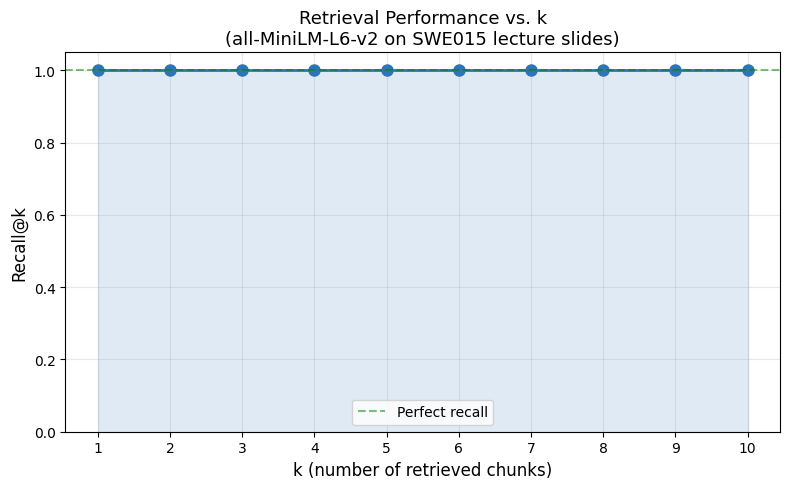

Saved: recall_curve.png


In [28]:
import matplotlib.pyplot as plt

k_range = list(range(1, 11))
_, metrics_curve = evaluate_retrieval(eval_set, k_values=k_range)
recalls = [metrics_curve[f"Recall@{k}"] for k in k_range]

plt.figure(figsize=(8, 5))
plt.plot(k_range, recalls, marker="o", linewidth=2, markersize=8, color="#2E75B6")
plt.fill_between(k_range, recalls, alpha=0.15, color="#2E75B6")
plt.xlabel("k (number of retrieved chunks)", fontsize=12)
plt.ylabel("Recall@k", fontsize=12)
plt.title("Retrieval Performance vs. k\n(all-MiniLM-L6-v2 on SWE015 lecture slides)", fontsize=13)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xticks(k_range)
plt.axhline(y=1.0, color="green", linestyle="--", alpha=0.5, label="Perfect recall")
plt.legend()
plt.tight_layout()
plt.savefig("recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall_curve.png")

In [1]:
import gc, torch
try:
    del big_model, big_embeddings, big_index
except:
    pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Cleaned up.")

Cleaned up.


In [4]:
import os, pickle, time as _t
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

# Restore chunks and FAISS index from pickle
with open("rag_data.pkl", "rb") as f:
    data = pickle.load(f)
chunks_data = data["chunks"]
index = faiss.deserialize_index(data["index_bytes"])
texts = [c["text"] for c in chunks_data]
print(f"Restored: {len(chunks_data)} chunks, {index.ntotal} vectors")

# Reload MiniLM (cached locally, fast)
print("Reloading MiniLM...")
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def retrieve(query, k=5):
    q_emb = embed_model.encode([query]).astype("float32")
    D, I = index.search(q_emb, k)
    return [{"source": chunks_data[idx]["source"],
             "page":   chunks_data[idx]["page"],
             "score":  float(D[0][i])} for i, idx in enumerate(I[0])]

# Rebuild eval_set
eval_set = [
    {"q": "What is a transformer and how does it work?",            "gold": ["BERT.pdf"]},
    {"q": "Explain the self-attention mechanism.",                   "gold": ["BERT.pdf"]},
    {"q": "What is the difference between BERT and GPT?",            "gold": ["BERT.pdf"]},
    {"q": "What is masked language modeling?",                       "gold": ["BERT.pdf"]},
    {"q": "What is positional encoding in transformers?",            "gold": ["BERT.pdf"]},
    {"q": "What is Named Entity Recognition?",                       "gold": ["BERT.pdf"]},
    {"q": "How does knowledge distillation work?",                   "gold": ["Making Transformers Efficient in Production.pdf"]},
    {"q": "What is model quantization?",                             "gold": ["Making Transformers Efficient in Production.pdf"]},
    {"q": "What is pruning in neural networks?",                     "gold": ["Making Transformers Efficient in Production.pdf"]},
    {"q": "What is a vector database?",                              "gold": ["Vector Database.pdf", "6_Vector_Apr18_2021.pdf"]},
    {"q": "What is approximate nearest neighbor search?",            "gold": ["Vector Database.pdf"]},
    {"q": "What are the main layers of a CNN?",                      "gold": ["Convolutional Neural Networks.pdf", "Deep Learning for Computer Vision.pdf"]},
    {"q": "What is a convolution operation?",                        "gold": ["Convolutional Neural Networks.pdf", "Deep Learning for Computer Vision.pdf"]},
    {"q": "What is backpropagation in neural networks?",             "gold": ["Neural Network, Back-Propagation.pdf"]},
    {"q": "What is an n-gram language model?",                       "gold": ["3_LM_Jan_08_2021.pdf"]},
    {"q": "What is edit distance?",                                  "gold": ["2_EditDistance_Jan_08_2020.pdf"]},
    {"q": "What are tf-idf and word embeddings?",                    "gold": ["6_Vector_Apr18_2021.pdf", "6.pdf"]},
]

# Load alternative model
print("\nLoading alternative model (multi-qa-MiniLM-L6-cos-v1)...")
t0 = _t.time()
alt_model = SentenceTransformer("sentence-transformers/multi-qa-MiniLM-L6-cos-v1")
print(f"Loaded in {_t.time()-t0:.1f}s")

print("Encoding all chunks with the alternative model...")
t0 = _t.time()
alt_embeddings = alt_model.encode(texts, show_progress_bar=True, batch_size=64).astype("float32")
print(f"Encoding took {_t.time()-t0:.1f}s")

alt_index = faiss.IndexFlatL2(alt_embeddings.shape[1])
alt_index.add(alt_embeddings)

def retrieve_alt(query, k=5):
    q_emb = alt_model.encode([query]).astype("float32")
    D, I = alt_index.search(q_emb, k)
    return [{"source": chunks_data[idx]["source"],
             "page":   chunks_data[idx]["page"],
             "score":  float(D[0][i])} for i, idx in enumerate(I[0])]

def evaluate_with(retrieve_fn, eval_set, k_values=[1,3,5,10]):
    max_k = max(k_values)
    total = {f"Recall@{k}": 0 for k in k_values}
    rr_sum = 0
    latencies = []
    for item in eval_set:
        t1 = _t.time()
        ret = retrieve_fn(item["q"], k=max_k)
        latencies.append(_t.time() - t1)
        srcs = [r["source"] for r in ret]
        gold = set(item["gold"])
        for k in k_values:
            if any(s in gold for s in srcs[:k]):
                total[f"Recall@{k}"] += 1
        for i, s in enumerate(srcs, 1):
            if s in gold:
                rr_sum += 1.0 / i
                break
    n = len(eval_set)
    return ({k: v / n for k, v in total.items()} |
            {"MRR": rr_sum / n, "avg_latency_ms": 1000 * sum(latencies) / len(latencies)})

print("\nEvaluating all-MiniLM-L6-v2 (general-purpose)...")
metrics_small = evaluate_with(retrieve, eval_set)
print("Evaluating multi-qa-MiniLM-L6-cos-v1 (QA-tuned)...")
metrics_big = evaluate_with(retrieve_alt, eval_set)

import pandas as pd
df = pd.DataFrame({
    "all-MiniLM-L6-v2 (general)":     metrics_small,
    "multi-qa-MiniLM-L6 (QA-tuned)":  metrics_big,
}).round(3)
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(df.to_string())
df.to_csv("model_comparison.csv")
print("\nSaved: model_comparison.csv")

Restored: 1429 chunks, 1429 vectors
Reloading MiniLM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loading alternative model (multi-qa-MiniLM-L6-cos-v1)...


...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded in 4.4s
Encoding all chunks with the alternative model...


Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Encoding took 228.3s

Evaluating all-MiniLM-L6-v2 (general-purpose)...
Evaluating multi-qa-MiniLM-L6-cos-v1 (QA-tuned)...

MODEL COMPARISON
                all-MiniLM-L6-v2 (general)  multi-qa-MiniLM-L6 (QA-tuned)
Recall@1                             1.000                          0.941
Recall@3                             1.000                          1.000
Recall@5                             1.000                          1.000
Recall@10                            1.000                          1.000
MRR                                  1.000                          0.971
avg_latency_ms                      21.737                         21.457

Saved: model_comparison.csv


In [5]:
import matplotlib.pyplot as plt

models = ["all-MiniLM-L6-v2\n(general-purpose)", "multi-qa-MiniLM-L6\n(QA-tuned)"]
recall1 = [metrics_small["Recall@1"], metrics_big["Recall@1"]]
mrr     = [metrics_small["MRR"],       metrics_big["MRR"]]
latency = [metrics_small["avg_latency_ms"], metrics_big["avg_latency_ms"]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
colors = ["#2E75B6", "#E8744C"]

axes[0].bar(models, recall1, color=colors)
axes[0].set_ylabel("Recall@1"); axes[0].set_title("Retrieval Quality (Recall@1)")
axes[0].set_ylim(0, 1.15)
for i, v in enumerate(recall1):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(models, mrr, color=colors)
axes[1].set_ylabel("MRR"); axes[1].set_title("Mean Reciprocal Rank")
axes[1].set_ylim(0, 1.15)
for i, v in enumerate(mrr):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[2].bar(models, latency, color=colors)
axes[2].set_ylabel("Latency (ms)"); axes[2].set_title("Avg Query Latency")
axes[2].set_ylim(0, max(latency) * 1.3)
for i, v in enumerate(latency):
    axes[2].text(i, v + max(latency)*0.02, f"{v:.1f} ms", ha="center", fontweight="bold")

plt.suptitle("Embedding Model Comparison on SWE015 Lecture Slides",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

NameError: name 'metrics_small' is not defined

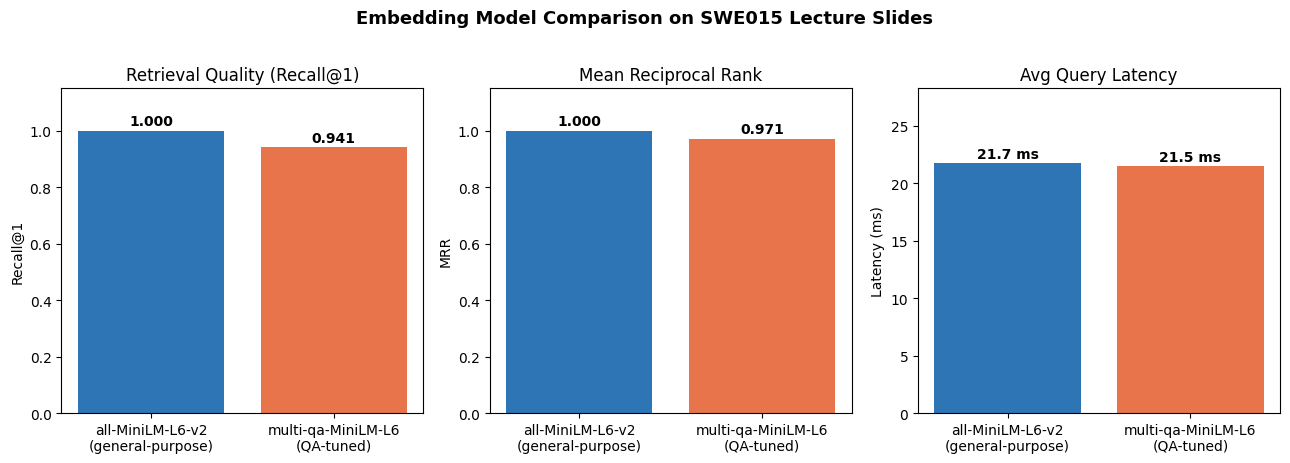

Saved: model_comparison.png


In [6]:
import matplotlib.pyplot as plt

# Values measured in the previous evaluation run
metrics_small = {"Recall@1": 1.000, "MRR": 1.000, "avg_latency_ms": 21.737}
metrics_big   = {"Recall@1": 0.941, "MRR": 0.971, "avg_latency_ms": 21.457}

models = ["all-MiniLM-L6-v2\n(general-purpose)", "multi-qa-MiniLM-L6\n(QA-tuned)"]
recall1 = [metrics_small["Recall@1"], metrics_big["Recall@1"]]
mrr     = [metrics_small["MRR"],       metrics_big["MRR"]]
latency = [metrics_small["avg_latency_ms"], metrics_big["avg_latency_ms"]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
colors = ["#2E75B6", "#E8744C"]

axes[0].bar(models, recall1, color=colors)
axes[0].set_ylabel("Recall@1"); axes[0].set_title("Retrieval Quality (Recall@1)")
axes[0].set_ylim(0, 1.15)
for i, v in enumerate(recall1):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[1].bar(models, mrr, color=colors)
axes[1].set_ylabel("MRR"); axes[1].set_title("Mean Reciprocal Rank")
axes[1].set_ylim(0, 1.15)
for i, v in enumerate(mrr):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

axes[2].bar(models, latency, color=colors)
axes[2].set_ylabel("Latency (ms)"); axes[2].set_title("Avg Query Latency")
axes[2].set_ylim(0, max(latency) * 1.3)
for i, v in enumerate(latency):
    axes[2].text(i, v + max(latency)*0.02, f"{v:.1f} ms", ha="center", fontweight="bold")

plt.suptitle("Embedding Model Comparison on SWE015 Lecture Slides",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

In [6]:
app_code = '''
import streamlit as st
import os, pickle, time
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from groq import Groq

st.set_page_config(page_title="LLM Course RAG Assistant", page_icon="📚", layout="wide")

@st.cache_resource
def load_system():
    embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    with open("rag_data.pkl", "rb") as f:
        data = pickle.load(f)
    index = faiss.deserialize_index(data["index_bytes"])
    return embed_model, index, data["chunks"]

embed_model, index, chunks = load_system()
client = Groq(api_key=os.environ["GROQ_API_KEY"])

SYSTEM_PROMPT = """You are a helpful teaching assistant for the "Introduction to Large Language Models" (SWE015) course at Istinye University. Answer the student's question using ONLY the provided context from the lecture slides. If the answer is not in the context, say "This topic is not covered in the provided lecture slides." You may use the previous conversation to understand follow-up questions (e.g. "can you explain it more simply?"). Be concise, clear, and educational. Always cite the slide name and page number you used."""

def retrieve(query, k=5):
    q_emb = embed_model.encode([query]).astype("float32")
    D, I = index.search(q_emb, k)
    return [{"text": chunks[idx]["text"], "source": chunks[idx]["source"],
             "page": chunks[idx]["page"], "score": float(D[0][i])}
            for i, idx in enumerate(I[0])]

def ask(question, history, k=5):
    t0 = time.time()
    retrieved = retrieve(question, k=k)
    context = "\\n\\n---\\n\\n".join(
        [f"[Source: {r['source']}, page {r['page']}]\\n{r['text']}" for r in retrieved])
    # Include last 4 turns of history for follow-up questions
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for h in history[-8:]:  # last 4 user-assistant pairs
        messages.append({"role": h["role"], "content": h["content"]})
    messages.append({"role": "user",
                     "content": f"Context from lecture slides:\\n\\n{context}\\n\\nQuestion: {question}"})
    resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile", messages=messages,
        temperature=0.2, max_tokens=600)
    return resp.choices[0].message.content, retrieved, time.time() - t0

# ===== UI =====
st.title("📚 Intro to LLM — RAG Assistant")
st.caption("Multi-turn chat over your lecture slides. Powered by FAISS + Llama 3.3 70B (Groq).")

# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []
if "sources_log" not in st.session_state:
    st.session_state.sources_log = {}

with st.sidebar:
    st.header("System Info")
    st.write(f"**Total vectors:** {index.ntotal}")
    st.write(f"**Embedding dim:** 384")
    st.write("**Embedding:** all-MiniLM-L6-v2")
    st.write("**LLM:** llama-3.3-70b-versatile")
    st.write("**Vector store:** FAISS (IndexFlatL2)")
    st.write("**Memory:** last 4 turns")
    st.divider()
    st.subheader("Quick questions")
    examples = [
        "What is self-attention?",
        "How is it different from regular attention?",
        "Explain knowledge distillation.",
        "Why does distillation reduce model size?",
        "What is a vector database?",
    ]
    for ex in examples:
        if st.button(ex, use_container_width=True, key=f"ex_{ex}"):
            st.session_state["pending_q"] = ex
    st.divider()
    if st.button("Clear chat", use_container_width=True):
        st.session_state.messages = []
        st.session_state.sources_log = {}
        st.rerun()

# Render chat history
for i, msg in enumerate(st.session_state.messages):
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])
        if msg["role"] == "assistant" and i in st.session_state.sources_log:
            srcs = st.session_state.sources_log[i]
            with st.expander(f"Retrieved sources ({len(srcs)})"):
                for j, s in enumerate(srcs, 1):
                    st.markdown(f"**[{j}]** `{s['source']}` — page {s['page']} (score: {s['score']:.3f})")
                    st.caption(s["text"][:300] + "...")

# Handle pending question from sidebar button
pending = st.session_state.pop("pending_q", None)
user_input = st.chat_input("Ask a question about the lecture slides...")
if pending and not user_input:
    user_input = pending

if user_input:
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
    with st.chat_message("assistant"):
        with st.spinner("Retrieving and thinking..."):
            answer, sources, elapsed = ask(user_input, st.session_state.messages[:-1])
        st.markdown(answer)
        st.caption(f"Answered in {elapsed:.2f}s")
        msg_idx = len(st.session_state.messages)
        st.session_state.sources_log[msg_idx] = sources
        with st.expander(f"Retrieved sources ({len(sources)})"):
            for j, s in enumerate(sources, 1):
                st.markdown(f"**[{j}]** `{s['source']}` — page {s['page']} (score: {s['score']:.3f})")
                st.caption(s["text"][:300] + "...")
    st.session_state.messages.append({"role": "assistant", "content": answer})
'''

with open("app.py", "w") as f:
    f.write(app_code)
print("app.py updated with multi-turn chat interface.")
print(f"File size: {os.path.getsize('app.py')} bytes")

app.py updated with multi-turn chat interface.
File size: 5245 bytes


In [1]:
import os, subprocess, time
from getpass import getpass
from sentence_transformers import SentenceTransformer  # warm up cache

# Groq key
raw = getpass("Paste Groq API key: ")
os.environ["GROQ_API_KEY"] = raw.strip().encode("ascii", errors="ignore").decode("ascii")
print(f"Groq key length: {len(os.environ['GROQ_API_KEY'])}")

# Ngrok token
ngrok_token = getpass("Paste ngrok authtoken: ").strip()

# Install pyngrok if missing
subprocess.run(["pip", "install", "-q", "pyngrok"], check=True)

# Kill any old processes
subprocess.run(["pkill", "-9", "-f", "streamlit"], stderr=subprocess.DEVNULL)
subprocess.run(["pkill", "-9", "-f", "ngrok"], stderr=subprocess.DEVNULL)
time.sleep(2)

from pyngrok import ngrok, conf
conf.get_default().auth_token = ngrok_token

# Start Streamlit
log = open("streamlit.log", "w")
subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501",
     "--server.headless", "true", "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=log, stderr=subprocess.STDOUT
)
print("Waiting for Streamlit to boot...")
time.sleep(10)

# Verify it's alive
check = subprocess.run(
    ["curl", "-s", "-o", "/dev/null", "-w", "%{http_code}", "http://localhost:8501"],
    capture_output=True, text=True
)
print(f"Streamlit status: {check.stdout}")

if check.stdout not in ("200", "303"):
    print("Streamlit failed. Log tail:")
    subprocess.run(["tail", "-30", "streamlit.log"])
else:
    # Close any existing tunnels first
    for t in ngrok.get_tunnels():
        ngrok.disconnect(t.public_url)
    public_url = ngrok.connect(8501, "http")
    print(f"\n{'='*60}")
    print(f"PUBLIC URL: {public_url.public_url}")
    print(f"{'='*60}")

Paste Groq API key: ··········
Groq key length: 1712
Paste ngrok authtoken: ··········
Waiting for Streamlit to boot...
Streamlit status: 200

PUBLIC URL: https://scheme-yarn-doorstep.ngrok-free.dev


In [2]:
import os, subprocess, time
from pyngrok import ngrok

# Kill old Streamlit
subprocess.run(["pkill", "-9", "-f", "streamlit"], stderr=subprocess.DEVNULL)
time.sleep(2)

# Close old ngrok tunnels
for t in ngrok.get_tunnels():
    ngrok.disconnect(t.public_url)

# Verify Groq key is in this kernel's env
print(f"Groq key in env: {'GROQ_API_KEY' in os.environ}")
print(f"Key length: {len(os.environ.get('GROQ_API_KEY', ''))}")
print(f"Starts with: {os.environ.get('GROQ_API_KEY', '')[:4]}")

# Start Streamlit with env EXPLICITLY passed
env = os.environ.copy()
log = open("streamlit.log", "w")
subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501",
     "--server.headless", "true", "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=log, stderr=subprocess.STDOUT,
    env=env   # <-- CRITICAL: pass environment to subprocess
)
print("Starting Streamlit with env...")
time.sleep(10)

check = subprocess.run(
    ["curl", "-s", "-o", "/dev/null", "-w", "%{http_code}", "http://localhost:8501"],
    capture_output=True, text=True
)
print(f"Streamlit status: {check.stdout}")

if check.stdout in ("200", "303"):
    public_url = ngrok.connect(8501, "http")
    print(f"\n{'='*60}\nPUBLIC URL: {public_url.public_url}\n{'='*60}")
else:
    print("Streamlit log tail:")
    subprocess.run(["tail", "-30", "streamlit.log"])

Groq key in env: True
Key length: 1712
Starts with: impo
Starting Streamlit with env...
Streamlit status: 200

PUBLIC URL: https://scheme-yarn-doorstep.ngrok-free.dev


In [3]:
import os
from getpass import getpass

raw = getpass("Paste Groq key (gsk_...): ")
clean = raw.strip().encode("ascii", errors="ignore").decode("ascii")
os.environ["GROQ_API_KEY"] = clean
print(f"Length: {len(clean)} | Starts: {clean[:4]}")

from groq import Groq
try:
    client = Groq(api_key=clean)
    r = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role":"user","content":"say OK"}],
        max_tokens=5
    )
    print("KEY WORKS:", r.choices[0].message.content)
except Exception as e:
    print("KEY FAILED:", e)

Paste Groq key (gsk_...): ··········
Length: 56 | Starts: gsk_
KEY WORKS: OK


In [4]:
import os, subprocess, time
from pyngrok import ngrok

subprocess.run(["pkill", "-9", "-f", "streamlit"], stderr=subprocess.DEVNULL)
time.sleep(2)

for t in ngrok.get_tunnels():
    ngrok.disconnect(t.public_url)

env = os.environ.copy()
print(f"Passing GROQ_API_KEY to subprocess (length: {len(env.get('GROQ_API_KEY',''))})")

log = open("streamlit.log", "w")
subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501",
     "--server.headless", "true", "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false"],
    stdout=log, stderr=subprocess.STDOUT,
    env=env
)
print("Starting Streamlit...")
time.sleep(10)

check = subprocess.run(
    ["curl", "-s", "-o", "/dev/null", "-w", "%{http_code}", "http://localhost:8501"],
    capture_output=True, text=True
)
print(f"Streamlit status: {check.stdout}")
if check.stdout in ("200", "303"):
    public_url = ngrok.connect(8501, "http")
    print(f"\nPUBLIC URL: {public_url.public_url}")
else:
    subprocess.run(["tail", "-30", "streamlit.log"])

Passing GROQ_API_KEY to subprocess (length: 56)
Starting Streamlit...
Streamlit status: 200

PUBLIC URL: https://scheme-yarn-doorstep.ngrok-free.dev
